# Mini-Projet : Analyse de Sentiment sur les Avis de Films
## Pipeline complet de Text Mining et Classification

## Objectif
""’objectif de ce mini-projet est de construire un pipeline complet de text mining
pour classifier des avis de films en deux classes : **positive** et **negative**.

Nous allons suivre les étapes suivantes :

1. **Exploration des données**
2. **Prétraitement du texte**
3. **Séparation des données en jeu d’entraînement et jeu de test**
4. **Vectorisation avec Bag-of-Words (BoW)**
5. **Réduction de dimension avec LSI**
6. **Classification avec la régression logistique**
7. **Évaluation des performances**
8. **Vectorisation avec TF-IDF**
9. **Réduction de dimension avec LSI**
10. **Classification avec la régression logistique**
11. **Évaluation des performances**
12. **Comparaison finale entre BoW et TF-IDF**""

In [2]:
# Importation des bibliothèques nécessaires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# Affichage plus propre des graphiques
plt.style.use("ggplot")

In [3]:
# Chargement du dataset CSV
df = pd.read_csv("IMDB Dataset.csv")

# Affichage des 5 premières lignes
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# Dimensions du dataset : (nombre de lignes, nombre de colonnes)
df.shape

(50000, 2)

In [5]:
# Afficher les noms des colonnes
df.columns

Index(['review', 'sentiment'], dtype='object')

In [6]:
# Informations générales sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
# Vérification des valeurs manquantes
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [8]:
# Nombre de lignes dupliquées
df.duplicated().sum()


418

In [9]:
# Répartition des classes
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [10]:
# Répartition des classes en pourcentage
df["sentiment"].value_counts(normalize=True) * 100

sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

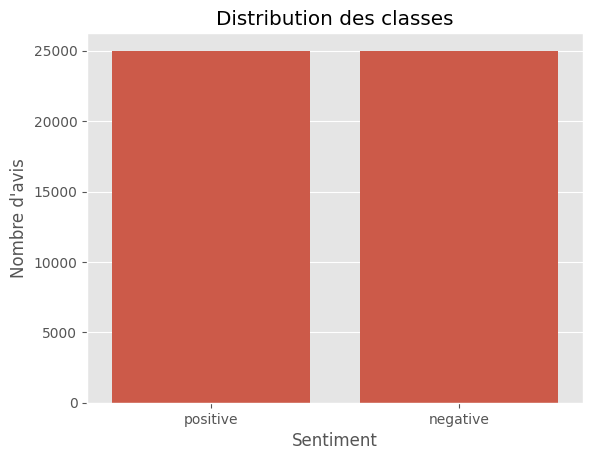

In [11]:
# Visualisation de la distribution des classes
sns.countplot(x="sentiment", data=df)
plt.title("Distribution des classes")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")
plt.show()

### Analyse
"La distribution des classes permet de vérifier si le dataset est équilibré."
"Un bon équilibre entre avis positifs et négatifs est favorable à l’apprentissage"
"du modèle de classification."

### Observation sur les doublons
"Le dataset contient 418 lignes dupliquées exactes sur 50 000 lignes."
"Ce nombre reste faible par rapport à la taille totale du corpus."
"Ces doublons correspondent à des avis et labels identiques."
"Ils pourront être supprimés afin d’éviter une légère redondance dans l’apprentissage."

In [12]:
# Afficher quelques lignes dupliquées exactes
df[df.duplicated()].head(10)


,review,sentiment
3537,Quite what the producers of this appalling ada...,negative
3769,My favourite police series of all time turns t...,positive
4391,"Beautiful film, pure Cassavetes style. Gena Ro...",positive
6352,If you liked the Grinch movie... go watch that...,negative
6479,I want very much to believe that the above quo...,negative
6672,Sigh. I'm baffled when I see a short like this...,negative
7221,"I have always been a huge fan of ""Homicide: Li...",positive
7222,There are plenty of comments already posted sa...,negative
7425,"The movie was excellent, save for some of the ...",positive
7555,This movie has made me upset! When I think of ...,negative


In [13]:
# Suppression des doublons exacts
df = df.drop_duplicates()

# Vérifier la nouvelle taille du dataset
df.shape


(49582, 2)

In [14]:
# Répartition des classes après suppression des doublons
df["sentiment"].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [ ]:
#étape  de l’exploration textuelle

In [15]:
# Calcul de la longueur de chaque avis en nombre de caractères
df["review_length"] = df["review"].apply(len)

# Aperçu des longueurs
df["review_length"].describe()

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64

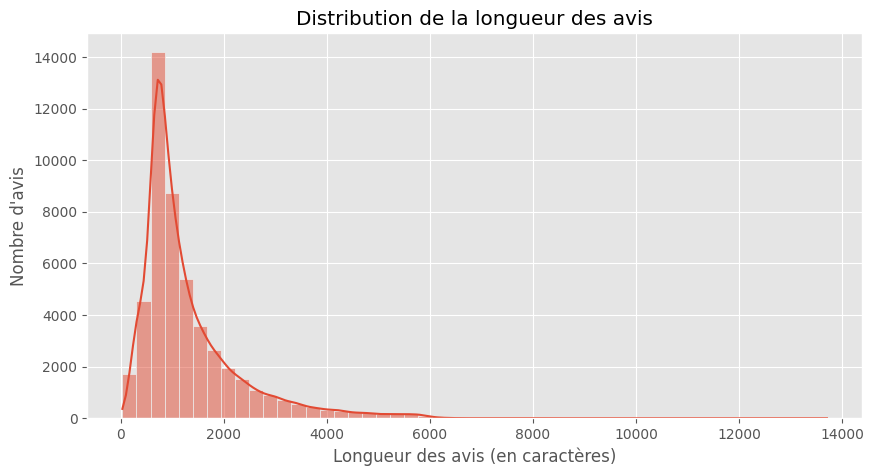

In [16]:
# Histogramme des longueurs des avis
plt.figure(figsize=(10, 5))
sns.histplot(df["review_length"], bins=50, kde=True)
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur des avis (en caractères)")
plt.ylabel("Nombre d'avis")
plt.show()

### Analyse
"La majorité des avis ont une longueur modérée, tandis que quelques avis très longs forment une longue traîne."
"Cela explique pourquoi la moyenne est supérieure à la médiane."

In [17]:
# Longueur moyenne des avis par classe
df.groupby("sentiment")["review_length"].mean()

sentiment
negative    1294.739615
positive    1326.278532
Name: review_length, dtype: float64

In [ ]:
#Etape prétraitement du texte.

In [18]:
# Étape de prétraitement de base du texte
def clean_text(text):
    # Mettre en minuscules
    text = text.lower()
    
    # Supprimer les balises HTML
    text = re.sub(r"<.*?>", " ", text)
    
    # Supprimer les chiffres
    text = re.sub(r"\d+", " ", text)
    
    # Supprimer la ponctuation et caractères spéciaux
    text = re.sub(r"[^\w\s]", " ", text)
    
    # Supprimer les underscores éventuels
    text = re.sub(r"_", " ", text)
    
    # Supprimer les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Appliquer le nettoyage
df["clean_review"] = df["review"].apply(clean_text)

# Comparer avant / après sur 5 lignes
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [ ]:
#la partie NLTK du prétraitemen

In [19]:
# Importer les outils NLTK nécessaires
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Télécharger les ressources nécessaires (à faire une seule fois)
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rania\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rania\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

"On applique maintenant :

""tokenisation
suppression des stopwords
stemming""

In [20]:
# Prétraitement NLP avec NLTK : tokenisation + stopwords + stemming
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_nltk(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)





In [21]:
print(preprocess_nltk("this is a very good movie")) #test sur une phrase 

good movi


In [22]:
df["clean_review"].head(5).apply(preprocess_nltk)

0    one review mention watch oz episod hook right ...
1    wonder littl product film techniqu unassum old...
2    thought wonder way spend time hot summer weeke...
3    basic famili littl boy jake think zombi closet...
4    petter mattei love time money visual stun film...
Name: clean_review, dtype: object

In [23]:
df["processed_review"] = df["clean_review"].apply(preprocess_nltk)

In [24]:
# Comparer avant / après
df[["clean_review", "processed_review"]].head()

,clean_review,processed_review
0,one of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...
1,a wonderful little production the filming tech...,wonder littl product film techniqu unassum old...
2,i thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,basically there s a family where a little boy ...,basic famili littl boy jake think zombi closet...
4,petter mattei s love in the time of money is a...,petter mattei love time money visual stun film...


In [ ]:
#Etape préparer les données pour le machine learning

"X = textes prétraités
"y = labels"
"séparation train / test"

In [25]:
# Préparation des données pour le modèle
from sklearn.model_selection import train_test_split

# Variable d'entrée : les avis prétraités
X = df["processed_review"]

# Variable cible : encoder positive=1 et negative=0
y = df["sentiment"].map({"positive": 1, "negative": 0})

# Séparation en jeu d'entraînement et jeu de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Vérification des tailles
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (39665,)
X_test  : (9917,)
y_train : (39665,)
y_test  : (9917,)


In [ ]:
#Etape vectorisation BOW

In [26]:
# Vectorisation BoW (Bag of Words)
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("X_train_bow :", X_train_bow.shape)
print("X_test_bow  :", X_test_bow.shape)

X_train_bow : (39665, 5000)
X_test_bow  : (9917, 5000)


In [27]:
# Étape : réduction de dimension sur la matrice BoW avec LSI
# L'objectif est de réduire le nombre de variables (5000 mots)
# en un nombre plus petit de dimensions latentes, afin de :
# - diminuer le bruit
# - alléger la matrice
# - préparer les données pour la classification

from sklearn.decomposition import TruncatedSVD

# Choix du nombre de dimensions latentes
n_components = 300

# Initialisation du modèle LSI / SVD tronquée
svd_bow = TruncatedSVD(n_components=n_components, random_state=42)

# Apprentissage sur les données d'entraînement BoW
# puis transformation des données train et test
X_train_bow_lsi = svd_bow.fit_transform(X_train_bow)
X_test_bow_lsi = svd_bow.transform(X_test_bow)

# Vérification des nouvelles dimensions
print("X_train_bow_lsi :", X_train_bow_lsi.shape)
print("X_test_bow_lsi  :", X_test_bow_lsi.shape)

X_train_bow_lsi : (39665, 300)
X_test_bow_lsi  : (9917, 300)


In [ ]:
#le modèle choisi : la régression logistique, appliquée sur BoW + LSI.

"Ce que cette cellule fait"
"entraîne la régression logistique"
"prédit les sentiments sur le jeu de test"
"stocke les résultats dans y_pred_bow"

In [28]:
# Étape : entraînement du modèle de classification sur BoW + LSI
# Nous utilisons la régression logistique pour prédire le sentiment :
# 1 = positive
# 0 = negative

from sklearn.linear_model import LogisticRegression

# Initialisation du modèle
logreg_bow = LogisticRegression(max_iter=1000, random_state=42)

# Entraînement du modèle sur les données d'entraînement réduites par LSI
logreg_bow.fit(X_train_bow_lsi, y_train)

# Prédiction sur les données de test
y_pred_bow = logreg_bow.predict(X_test_bow_lsi)

# Afficher quelques prédictions pour vérification
print("Premières prédictions :", y_pred_bow[:10])

Premières prédictions : [0 1 1 0 0 1 0 0 1 0]


In [29]:
# Étape : évaluation de performances BoW + LSI + Régression logistique(modéle)
# Ici, on mesure la qualité des prédictions obtenues avec le pipeline déjà construit.
# Nous calculons les métriques demandées  :
# - accuracy
# - precision
# - recall
# - F1-score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calcul des métriques
accuracy_bow = accuracy_score(y_test, y_pred_bow)
precision_bow = precision_score(y_test, y_pred_bow)
recall_bow = recall_score(y_test, y_pred_bow)
f1_bow = f1_score(y_test, y_pred_bow)

# Affichage des résultats
print("Accuracy  :", accuracy_bow)
print("Precision :", precision_bow)
print("Recall    :", recall_bow)
print("F1-score  :", f1_bow)

# Rapport de classification détaillé
print("\nRapport de classification :\n")
print(classification_report(y_test, y_pred_bow))

Accuracy  : 0.8621558939195321
Precision : 0.8525390625
Recall    : 0.8770343580470162
F1-score  : 0.8646132514608299

Rapport de classification :

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4940
           1       0.85      0.88      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



### Analyse des résultats du pipeline BoW + LSI + régression logistique
""Le modèle obtient une accuracy d’environ 86 %, avec un F1-score proche de 0.865.
Les performances sont équilibrées entre les deux classes, ce qui montre que le modèle
parvient globalement à bien distinguer les avis positifs et négatifs.
Le recall est légèrement plus élevé que la precision, ce qui signifie que le modèle
"retrouve bien les avis positifs, avec quelques faux positifs supplémentaires.
Pour le pipeline texte prétraité → BoW → LSI → régression logistique

Accuracy = 0.862
Precision = 0.853
Recall = 0.877
F1-score = 0.865

Donc, le modèle classe correctement environ 86 % des avis.
C’est un résultat solide pour ce type de mini-projet.

Ce que dit le rapport
Classe 0 : precision ≈ 0.87, recall ≈ 0.85
Classe 1 : precision ≈ 0.85, recall ≈ 0.88

Donc le modèle est assez équilibré sur les deux classes, ce qui est bien.
Il n’y a pas une classe complètement négligée.""

In [30]:
# Étape : vectorisation TF-IDF
# Contrairement à BoW, TF-IDF pondère les mots selon leur importance
# dans le document et dans l'ensemble du corpus.

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("X_train_tfidf :", X_train_tfidf.shape)
print("X_test_tfidf  :", X_test_tfidf.shape)

X_train_tfidf : (39665, 5000)
X_test_tfidf  : (9917, 5000)


In [31]:
#LSI sur TF-IDF
# Étape : réduction de dimension sur la matrice TF-IDF avec LSI
# Comme pour BoW, nous réduisons les 5000 variables TF-IDF
# en un nombre plus petit de dimensions latentes.

from sklearn.decomposition import TruncatedSVD

# Choix du nombre de dimensions latentes
n_components = 300

# Initialisation du modèle LSI / SVD tronquée
svd_tfidf = TruncatedSVD(n_components=n_components, random_state=42)

# Apprentissage sur les données d'entraînement TF-IDF
# puis transformation des données train et test
X_train_tfidf_lsi = svd_tfidf.fit_transform(X_train_tfidf)
X_test_tfidf_lsi = svd_tfidf.transform(X_test_tfidf)

# Vérification des nouvelles dimensions
print("X_train_tfidf_lsi :", X_train_tfidf_lsi.shape)
print("X_test_tfidf_lsi  :", X_test_tfidf_lsi.shape)

X_train_tfidf_lsi : (39665, 300)
X_test_tfidf_lsi  : (9917, 300)


In [32]:
#etape régression logistique sur TF-IDF
# Étape : entraînement du modèle de classification sur TF-IDF + LSI
# Nous utilisons le même modèle que pour BoW afin de comparer
# uniquement l'effet de la vectorisation.

from sklearn.linear_model import LogisticRegression

# Initialisation du modèle
logreg_tfidf = LogisticRegression(max_iter=1000, random_state=42)

# Entraînement du modèle sur les données d'entraînement réduites par LSI
logreg_tfidf.fit(X_train_tfidf_lsi, y_train)

# Prédiction sur les données de test
y_pred_tfidf = logreg_tfidf.predict(X_test_tfidf_lsi)

# Afficher quelques prédictions pour vérification
print("Premières prédictions :", y_pred_tfidf[:10])

Premières prédictions : [0 1 1 0 0 1 0 0 1 0]


In [33]:
#Etape d'évaluationn  les performances du pipeline TF-IDFavec :
"accuracy"
"precision"
"recall"
"F1-score "
# Étape : évaluation des performances du pipeline TF-IDF + LSI + régression logistique
# Ici, on mesure la qualité des prédictions obtenues
# avec le pipeline déjà construit.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calcul des métriques
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
precision_tfidf = precision_score(y_test, y_pred_tfidf)
recall_tfidf = recall_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf)

# Affichage des résultats
print("Accuracy  :", accuracy_tfidf)
print("Precision :", precision_tfidf)
print("Recall    :", recall_tfidf)
print("F1-score  :", f1_tfidf)

# Rapport de classification détaillé
print("\nRapport de classification :\n")
print(classification_report(y_test, y_pred_tfidf))

Accuracy  : 0.8718362407986286
Precision : 0.8612085769980506
Recall    : 0.8876833433795459
F1-score  : 0.8742455723755813

Rapport de classification :

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4940
           1       0.86      0.89      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



In [34]:
#tableau récapitulatif comparant BoW et TF-IDF
# Étape : création du tableau comparatif des résultats
# Ce tableau récapitule les performances des deux pipelines :
# 1) BoW + LSI + régression logistique
# 2) TF-IDF + LSI + régression logistique

results_df = pd.DataFrame({
    "Vectorisation": ["BoW", "TF-IDF"],
    "Accuracy": [accuracy_bow, accuracy_tfidf],
    "Precision": [precision_bow, precision_tfidf],
    "Recall": [recall_bow, recall_tfidf],
    "F1-score": [f1_bow, f1_tfidf]
})

# Arrondir les valeurs pour un affichage plus lisible
results_df = results_df.round(4)

# Afficher le tableau comparatif
results_df

,Vectorisation,Accuracy,Precision,Recall,F1-score
0,BoW,0.8622,0.8525,0.8770,0.8646
1,TF-IDF,0.8718,0.8612,0.8877,0.8742


## Analyse comparative : BoW vs TF-IDF

""Le tableau comparatif montre que la vectorisation **TF-IDF**  est la meilleure vectorisation il  donne de meilleurs résultats que **BoW** sur l’ensemble des métriques évaluées : accuracy, precision, recall et F1-score.

Cela s’explique par le fait que **TF-IDF** ne se contente pas de compter les mots comme BoW. Elle pondère également les termes selon leur importance dans le document et dans le corpus. Ainsi, les mots très fréquents mais peu informatifs ont moins d’influence, tandis que les mots plus discriminants ont davantage de poids.

Dans notre mini-projet, le pipeline **TF-IDF + LSI + régression logistique** est donc le plus performant pour la classification des avis de films en sentiments positifs et négatifs.""

In [35]:
# Étape : afficher les mots les plus fréquents du corpus
# Cette cellule permet de compléter la partie exploration textuelle
# en identifiant les mots les plus fréquents après prétraitement.

from collections import Counter

# Concaténer tous les textes prétraités
all_words = " ".join(df["processed_review"]).split()

# Compter la fréquence des mots
word_freq = Counter(all_words)

# Afficher les 20 mots les plus fréquents
word_freq.most_common(20)

[('movi', 102503),
 ('film', 95233),
 ('one', 55040),
 ('like', 44836),
 ('time', 31702),
 ('good', 29989),
 ('make', 29831),
 ('charact', 28129),
 ('see', 28006),
 ('get', 27754),
 ('watch', 27616),
 ('even', 25153),
 ('stori', 25121),
 ('would', 24401),
 ('realli', 22924),
 ('well', 21632),
 ('scene', 21300),
 ('look', 19787),
 ('show', 19675),
 ('much', 19153)]

### Analyse des mots les plus fréquents
""Les mots les plus fréquents après prétraitement sont liés au domaine du cinéma, comme `movi`, `film`, `charact`, `scene` et `stori`, ce qui est cohérent avec un corpus d’avis de films.

On remarque également que certains mots sont raccourcis (`movi`, `stori`, `realli`) à cause du stemming appliqué lors du prétraitement.

Ces mots sont fréquents dans l’ensemble du corpus, mais ils ne sont pas forcément les plus discriminants pour distinguer les avis positifs et négatifs.""

In [36]:
# Installer la bibliothèque wordcloud dans l'environnement Jupyter
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


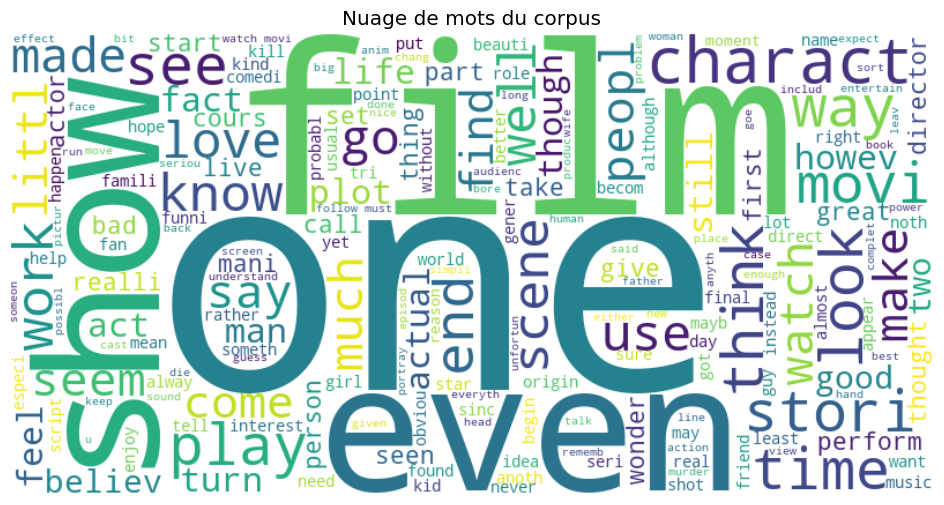

In [37]:
# Étape : génération d'un nuage de mots (WordCloud)
# Cette visualisation permet de représenter les mots les plus fréquents
# du corpus de manière visuelle.

from wordcloud import WordCloud

# Reconstituer le texte global à partir des avis prétraités
text_corpus = " ".join(df["processed_review"])

# Générer le nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_corpus)

# Afficher le nuage de mots
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots du corpus")
plt.show()

### Analyse du nuage de mots
""Le nuage de mots met en évidence les termes les plus fréquents du corpus, comme `film`, `movi`, `character`, `show`, `story` et `scene`.
Ces mots sont cohérents avec la nature du dataset, constitué d’avis de films.
On remarque également l’effet du stemming, qui transforme certains mots en racines comme `movi` pour `movie`.
Cette visualisation confirme les résultats obtenus avec l’analyse des fréquences de mots.""

In [38]:
# Étape : mots les plus fréquents par classe
# Cette cellule complète l'exploration textuelle en identifiant
# les mots les plus fréquents dans les avis positifs et négatifs séparément.

from collections import Counter
import pandas as pd

# Récupérer les textes prétraités de chaque classe
positive_words = " ".join(df[df["sentiment"] == "positive"]["processed_review"]).split()
negative_words = " ".join(df[df["sentiment"] == "negative"]["processed_review"]).split()

# Compter la fréquence des mots dans chaque classe
positive_freq = Counter(positive_words)
negative_freq = Counter(negative_words)

# Extraire les 20 mots les plus fréquents
top_positive = positive_freq.most_common(20)
top_negative = negative_freq.most_common(20)

# Transformer en DataFrame pour un affichage plus lisible
top_words_by_class = pd.DataFrame({
    "Top mots positifs": [word for word, freq in top_positive],
    "Fréquence positifs": [freq for word, freq in top_positive],
    "Top mots négatifs": [word for word, freq in top_negative],
    "Fréquence négatifs": [freq for word, freq in top_negative]
})

# Afficher le tableau
top_words_by_class

,Top mots positifs,Fréquence positifs,Top mots négatifs,Fréquence négatifs
0,film,50734,movi,57864
1,movi,44639,film,44499
2,one,28176,one,26864
3,like,20484,like,24352
4,time,16564,make,16070
5,good,15203,even,15277
6,see,15083,time,15138
7,stori,14151,get,15111
8,charact,13967,good,14786
9,make,13761,watch,14778


### Analyse des mots fréquents par classe
L’analyse des mots les plus fréquents par classe montre que certains termes sont communs aux avis positifs et négatifs, comme `film`, `movi`, `watch` et `charact`, car ils appartiennent au vocabulaire général du domaine cinématographique.

Cependant, certains mots apparaissent comme plus représentatifs d’un sentiment donné. Par exemple, `love`, `great` et `good` sont davantage associés aux avis positifs, tandis que `bad` apparaît parmi les mots fréquents des avis négatifs.

Cela montre que tous les mots fréquents ne sont pas forcément discriminants, ce qui aide à comprendre pourquoi une pondération comme **TF-IDF** peut être plus efficace que **BoW**.